# TASK-7: Get Basic Sales Summary from a Tiny SQLite Database using Python


In [2]:
#Importing neccessary Libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Step 1: Create the database and insert sample course sales data
def create_database():
    conn = sqlite3.connect("course_sales.db")
    cursor = conn.cursor()

    # Create the sales table
    cursor.execute("""
    CREATE TABLE IF NOT EXISTS sales (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        course TEXT,
        enrollments INTEGER,
        price REAL
    )
    """)

    # Insert sample data
    sample_data = [
        ("Python Basics", 120, 25.0),
        ("Data Science", 80, 40.0),
        ("Web Dev", 60, 30.0),
        ("Python Basics", 30, 25.0)
    ]

    cursor.executemany("INSERT INTO sales (course, enrollments, price) VALUES (?, ?, ?)", sample_data)

    conn.commit()
    conn.close()


In [4]:
# Step 2: Query the database for summary
def query_sales_data():
    conn = sqlite3.connect("course_sales.db")
    query = """
    SELECT 
        course, 
        SUM(enrollments) AS total_enrollments, 
        SUM(enrollments * price) AS revenue 
    FROM sales 
    GROUP BY course
    """
    df = pd.read_sql_query(query, conn)
    conn.close()
    return df

Course Sales Summary:
          course  total_enrollments  revenue
0   Data Science                 80   3200.0
1  Python Basics                150   3750.0
2        Web Dev                 60   1800.0


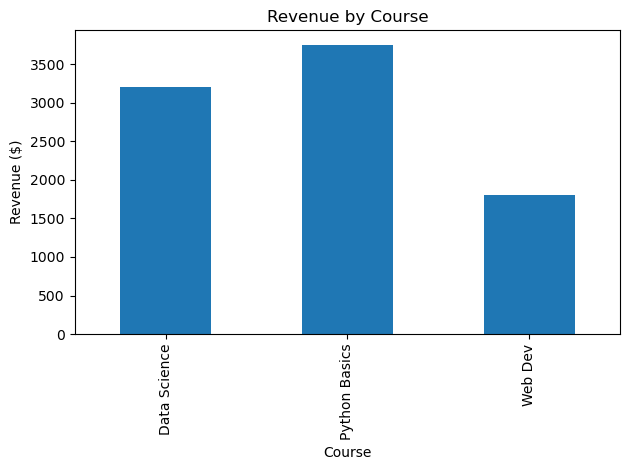

In [5]:
# Step 3: Display and visualize
def display_results(df):
    print("Course Sales Summary:")
    print(df)

    # Plot revenue bar chart
    df.plot(kind='bar', x='course', y='revenue', legend=False)
    plt.title("Revenue by Course")
    plt.ylabel("Revenue ($)")
    plt.xlabel("Course")
    plt.tight_layout()
    plt.savefig("course_sales_chart.png")
    plt.show()

# Run all steps
if __name__ == "__main__":
    create_database()
    df = query_sales_data()
    display_results(df)
